# Label Encoding vs One-Hot Encoding
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Comparing LabelEncoder and one-hot encoding on categorical columns.

### Main goals:

- Show how LabelEncoder assigns numeric codes.
- Demonstrate the false ordering LabelEncoder can introduce.
- Apply one-hot encoding and compare against LabelEncoder.
- Decide when ordinal mapping is appropriate vs one-hot.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## LabelEncoder

In [2]:
df = pd.DataFrame({
    'education':     ['Undergraduate', 'Graduate', 'Postgraduate', 'Graduate', 'Undergraduate'],
    'property_area': ['Urban', 'Semiurban', 'Rural', 'Urban', 'Rural'],
    'loan_status':   ['Y', 'N', 'Y', 'Y', 'N']
})

le_education = LabelEncoder()
df['education_encoded'] = le_education.fit_transform(df['education'])
print(df[['education', 'education_encoded']])
print('Classes:', le_education.classes_)

       education  education_encoded
0  Undergraduate                  2
1       Graduate                  0
2   Postgraduate                  1
3       Graduate                  0
4  Undergraduate                  2
Classes: ['Graduate' 'Postgraduate' 'Undergraduate']


**Observation:**
LabelEncoder assigns numbers alphabetically, not by any logical ordering — Graduate=0, Postgraduate=1, Undergraduate=2.

In [3]:
le_area = LabelEncoder()
df['property_area_encoded'] = le_area.fit_transform(df['property_area'])
print(df[['property_area', 'property_area_encoded']])
print('Classes:', le_area.classes_)

  property_area  property_area_encoded
0         Urban                      2
1     Semiurban                      1
2         Rural                      0
3         Urban                      2
4         Rural                      0
Classes: ['Rural' 'Semiurban' 'Urban']


## The Ordering Problem

In [4]:
print(f'|Rural - Semiurban| = {abs(0-1)}')
print(f'|Rural - Urban|     = {abs(0-2)}')
print(f'|Semiurban - Urban| = {abs(1-2)}')

|Rural - Semiurban| = 1
|Rural - Urban|     = 2
|Semiurban - Urban| = 1


**Observation:**
This implies Rural↔Urban is twice as different as Rural↔Semiurban. That relationship is an alphabetical accident, not a real property of the data.

## One-Hot Encoding

In [5]:
df_onehot = pd.get_dummies(df[['property_area']], columns=['property_area'])
df_onehot

,property_area_Rural,property_area_Semiurban,property_area_Urban
0,False,False,True
1,False,True,False
2,True,False,False
3,False,False,True
4,True,False,False


In [6]:
df_onehot_dropfirst = pd.get_dummies(df[['property_area']], columns=['property_area'], drop_first=True)
print(df_onehot_dropfirst)
print('Columns saved:', df_onehot.shape[1] - df_onehot_dropfirst.shape[1])

   property_area_Semiurban  property_area_Urban
0                    False                 True
1                     True                False
2                    False                False
3                    False                 True
4                    False                False
Columns saved: 1


**Observation:**
`drop_first` is worth using on high-cardinality columns — Cabin deck in Spaceship Titanic could add many columns without it.

## Visual Comparison

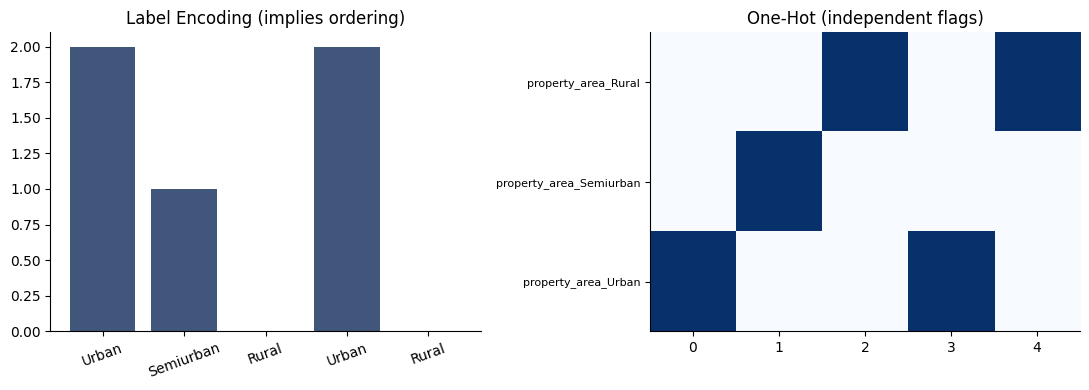

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(len(df)), df['property_area_encoded'], color='#1F3864', alpha=0.85)
axes[0].set_xticks(range(len(df)))
axes[0].set_xticklabels(df['property_area'], rotation=20)
axes[0].set_title('Label Encoding (implies ordering)')

onehot_numeric = df_onehot.astype(int)
axes[1].imshow(onehot_numeric.T, cmap='Blues', aspect='auto', vmin=0, vmax=1)
axes[1].set_yticks(range(len(onehot_numeric.columns)))
axes[1].set_yticklabels(onehot_numeric.columns, fontsize=8)
axes[1].set_title('One-Hot (independent flags)')

plt.tight_layout()
plt.show()

## When Ordinal Mapping Makes Sense

In [8]:
education_order = ['Undergraduate', 'Graduate', 'Postgraduate']
df['education_ordinal'] = df['education'].map({cat: i for i, cat in enumerate(education_order)})
df[['education', 'education_ordinal']]

,education,education_ordinal
0,Undergraduate,0
1,Graduate,1
2,Postgraduate,2
3,Graduate,1
4,Undergraduate,0


**Observation:**
Education has a genuine order, so a deliberate ordinal mapping is appropriate. Property_Area and HomePlanet have no inherent order, so one-hot is the safer default for those.